# 04 · Modelo de grafo para minimizar horas semanales

Este notebook implementa el enfoque operativo correcto:

- La volumetria semanal por SKU es fija.
- El modelo aprende un grafo dirigido por linea usando el historico 2025.
- Cada arco `SKU_origen -> SKU_destino` representa el coste horario esperado de poner un SKU detras de otro.
- El objetivo es producir el mismo volumen en el menor numero de horas.
- Mas horas sobrantes significa mejor combinacion/secuencia.

El modelo usa solo informacion de 2025 para decidir si un SKU puede producirse en una linea. Si un SKU de la semana no aparece en ninguna linea compatible del historico 2025, queda marcado como no modelable en modo estricto.

## 0 · Restricciones de planta

Restricciones fisicas de formato:

- L14: `1/2` y `1/3`.
- L17: solo `1/3`.
- L19: `1/2`, `1/3` y `2/5`.

Restriccion de evidencia historica:

- Un SKU solo es elegible en una linea si ese SKU exacto se produjo en esa linea en 2025.

Modelo de horas:

```text
horas_linea = horas_produccion + horas_transicion_grafo
horas_sobrantes = capacidad_linea - horas_linea
```

La penalizacion de OEE se pasa a horas equivalentes porque, a volumen fijo, peor OEE implica mas tiempo real para producir la misma cantidad.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loaders import (
    load_all_operations,
    load_diario_hl,
    weekly_demand_from_diario,
    original_sequences_from_diario,
)
from post_mortem import PostMortemAnalyzer
from scheduling_cp_sat import (
    LINES,
    LINE_ALLOWED_FORMATS,
    build_line_behavior_graphs,
    build_line_sku_eligibility,
    summarize_eligibility,
    prepare_throughput,
    run_weekly_graph_hours_optimizer,
)

sns.set_theme(style='whitegrid', font_scale=1.05)
DATA_DIR = Path('../raw_data')
HOURS_PER_WEEK = {'14': 110, '17': 115, '19': 115}
print('Capacidad semanal:', HOURS_PER_WEEK)


Capacidad semanal: {'14': 110, '17': 115, '19': 115}


## 1 · Carga de datos y post-mortem 2025

In [2]:
dfs = load_all_operations(DATA_DIR)
df_diario = load_diario_hl(DATA_DIR / 'Diario Hl_Planif.xlsx')
demanda_semanal = weekly_demand_from_diario(df_diario)
original_sequences = original_sequences_from_diario(df_diario)

analyzer = PostMortemAnalyzer(
    df_oee=dfs['oee'],
    df_cambios=dfs['cam'],
    df_mantenimiento=dfs['mant'],
    df_tiempo=dfs['tiem'],
    df_volumen=dfs['vol'],
)
analyzer.clean_and_isolate_maintenance()
matrices = analyzer.build_transition_matrices()
graphs = build_line_behavior_graphs(matrices)
throughput = prepare_throughput(dfs)

print(f"Demanda semanal: {demanda_semanal['sku'].nunique()} SKUs | {demanda_semanal['hl_total'].sum():,.1f} HL")
print('\nSecuencia original por linea:')
for line, seq in original_sequences.items():
    print(f"  L{line}: {' -> '.join(seq)}")
print('\nGrafo aprendido por línea (nodos = marca × volumen × pack × envase):')
for line, graph in graphs.items():
    print(f"  L{line}: {graph.number_of_nodes()} nodos | {graph.number_of_edges()} aristas")


[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 236 transiciones únicas (59 nodos origen, 60 nodos destino)
[build_transition_matrices] Línea 17: 567 transiciones únicas (94 nodos origen, 93 nodos destino)
[build_transition_matrices] Línea 19: 555 transiciones únicas (115 nodos origen, 113 nodos destino)
Demanda semanal: 28 SKUs | 36,933.5 HL

Secuencia original por linea:
  L14: ED13LP24 -> FDT13LT -> VO13LTNN
  L17: ED13LP24 -> FD13LTNN -> VI1324MM -> XI13LTN -> XI13P24M -> DL13LT -> FDL13LN -> KE13LTNN -> TU13LTN -> TUP13LT -> KE13PL12 -> LC13LTNN -> SK13LN
  L19: EN12B24I -> EX12LB24 -> EX12LBN -> XI13L12M -> ED12LTW -> VO12LT -> DL12LT -> EN13L24B -> EX1324NB -> ID12LBN -> LC12LTW -> VI12LTW -> VI12LTX

Grafo aprendido por línea (nodos = marca × volumen × pack × envase):
  L14: 63 nodos | 236 aristas
  L17: 94 nodos | 567 aristas
  L19: 117 nodos | 555 aristas


## 2 · Validacion de elegibilidad SKU-linea

In [3]:
eligibility = build_line_sku_eligibility(dfs, demanda_semanal)
eligibility_summary = summarize_eligibility(eligibility)

print('Formatos permitidos por linea:', LINE_ALLOWED_FORMATS)
print('\nResumen de elegibilidad:')
print(eligibility_summary.to_string(index=False))

ineligible = eligibility_summary[eligibility_summary['n_eligible_lines'] == 0]
print(f"\nSKUs sin linea elegible exacta en historico 2025: {len(ineligible)}")
if not ineligible.empty:
    print(ineligible[['sku', 'format', 'reason']].to_string(index=False))

Formatos permitidos por linea: {'14': {'1/3', '1/2'}, '17': {'1/3'}, '19': {'2/5', '1/3', '1/2'}}

Resumen de elegibilidad:
     sku format eligible_lines  n_eligible_lines         reason
ED13LP24    1/3       14,17,19                 3 histórico 2025
 FDT13LT    1/3          14,17                 2 histórico 2025
VO13LTNN    1/3       14,17,19                 3 histórico 2025
  DL13LT    1/3          14,17                 2 histórico 2025
FD13LTNN    1/3          14,17                 2 histórico 2025
 FDL13LN    1/3       14,17,19                 3 histórico 2025
KE13LTNN    1/3          14,17                 2 histórico 2025
KE13PL12    1/3          17,19                 2 histórico 2025
LC13LTNN    1/3          14,17                 2 histórico 2025
  SK13LN    1/3       14,17,19                 3 histórico 2025
 TU13LTN    1/3          14,17                 2 histórico 2025
 TUP13LT    1/3          14,17                 2 histórico 2025
VI1324MM    1/3             17              

## 3 · Resolver modo estricto

Primero se intenta resolver la semana completa cumpliendo todas las reglas. Si hay SKUs sin evidencia historica exacta, el modelo no fuerza una recomendacion falsa: devuelve la lista de SKUs no modelables.

In [4]:
strict_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=demanda_semanal,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=original_sequences,
    time_limit=60.0,
    drop_ineligible=False,
)

print('Estado estricto:', strict_results.get('_status') if isinstance(strict_results, dict) else strict_results)
if isinstance(strict_results, dict) and strict_results.get('_ineligible_skus'):
    print('SKUs que impiden resolver la semana completa en modo estricto:')
    print(', '.join(strict_results['_ineligible_skus']))

Estado estricto: FEASIBLE


## 4 · Demo del solver sobre SKUs cubiertos por historico

Para ver el funcionamiento del modelo, resolvemos el subconjunto de SKUs que si tienen evidencia exacta en 2025. Esta celda no pretende ocultar los SKUs no cubiertos; sirve para demostrar el motor combinatorio con datos estrictamente aprendidos del historico.

In [5]:
results = run_weekly_graph_hours_optimizer(
    demanda_semanal=demanda_semanal,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=original_sequences,
    time_limit=60.0,
    drop_ineligible=True,
)

print('Estado demo:', results['_status'])
print(f"SKUs modelados: {len(results['_demand_modeled'])} / {len(demanda_semanal)}")
print(f"HL modelados: {results['_demand_modeled']['hl_total'].sum():,.1f} / {demanda_semanal['hl_total'].sum():,.1f}")

Estado demo: FEASIBLE
SKUs modelados: 28 / 28
HL modelados: 36,933.5 / 36,933.5


## 4.1 · Variante: mantener linea original y solo reordenar

El bloque anterior permite reasignar SKUs entre lineas elegibles para minimizar horas. Esta variante mantiene cada SKU en su linea original y optimiza solo la secuencia, aplicando la misma regla de evidencia historica 2025.


In [6]:
fixed_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=demanda_semanal,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=original_sequences,
    time_limit=60.0,
    drop_ineligible=True,
    fixed_original_lines=True,
)

print('Estado linea fija:', fixed_results['_status'])
print(f"SKUs modelados: {len(fixed_results['_demand_modeled'])} / {len(demanda_semanal)}")
print(f"HL modelados: {fixed_results['_demand_modeled']['hl_total'].sum():,.1f} / {demanda_semanal['hl_total'].sum():,.1f}")
conflicts = fixed_results.get('_fixed_line_conflicts', pd.DataFrame())
if not conflicts.empty:
    print('SKUs descartados por no poder quedarse en su linea original con evidencia 2025:')
    print(conflicts.to_string(index=False))

fixed_summary_rows = []
for line in LINES:
    r = fixed_results.get(line)
    if not r:
        continue
    fixed_summary_rows.append({
        'linea': line,
        'horas_original': r['hours_original'],
        'horas_optimizadas': r['hours_optimized'],
        'horas_liberadas_vs_original': r['hours_saved'],
        'horas_sobrantes': r['spare_hours'],
        'capacity_ok': r['capacity_ok'],
        'secuencia_optimizada': ' -> '.join(r['seq_optimized']),
    })
fixed_summary = pd.DataFrame(fixed_summary_rows)
print(fixed_summary.to_string(index=False, float_format='{:.2f}'.format))


Estado linea fija: FEASIBLE
SKUs modelados: 28 / 28
HL modelados: 36,933.5 / 36,933.5
linea  horas_original  horas_optimizadas  horas_liberadas_vs_original  horas_sobrantes  capacity_ok                                                                                                                           secuencia_optimizada
   14           70.62              70.62                         0.00            39.38         True                                                                                                                ED13LP24 -> FDT13LT -> VO13LTNN
   17           94.96              94.96                         0.00            20.04         True           FD13LTNN -> VI1324MM -> XI13LTN -> XI13P24M -> DL13LT -> FDL13LN -> KE13LTNN -> TU13LTN -> TUP13LT -> KE13PL12 -> LC13LTNN -> SK13LN
   19          101.47             101.47                         0.00            13.53         True EN12B24I -> EX12LB24 -> EX12LBN -> XI13L12M -> ED12LTW -> VO12LT -> DL12LT -> EN13L24

## 5 · Resultado: horas usadas, horas sobrantes y secuencia

In [7]:
summary_rows = []
for line in LINES:
    r = results.get(line)
    if not r:
        continue
    summary_rows.append({
        'linea': line,
        'horas_original': r['hours_original'],
        'horas_optimizadas': r['hours_optimized'],
        'horas_liberadas_vs_original': r['hours_saved'],
        'horas_sobrantes': r['spare_hours'],
        'prod_h': r['prod_hours'],
        'transicion_grafo_h': r['transition_hours'],
        'capacity_ok': r['capacity_ok'],
        'secuencia_optimizada': ' -> '.join(r['seq_optimized']),
    })
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False, float_format='{:.2f}'.format))
print('\nTotal horas optimizadas:', summary['horas_optimizadas'].sum().round(2))
print('Total horas sobrantes:', summary['horas_sobrantes'].sum().round(2))

linea  horas_original  horas_optimizadas  horas_liberadas_vs_original  horas_sobrantes  prod_h  transicion_grafo_h  capacity_ok                                                                                                                           secuencia_optimizada
   14           70.62              70.62                         0.00            39.38   68.62                2.00         True                                                                                                                ED13LP24 -> FDT13LT -> VO13LTNN
   17           94.96              94.96                         0.00            20.04   83.96               11.00         True           FD13LTNN -> VI1324MM -> XI13LTN -> XI13P24M -> DL13LT -> FDL13LN -> KE13LTNN -> TU13LTN -> TUP13LT -> KE13PL12 -> LC13LTNN -> SK13LN
   19          101.47             101.47                         0.00            13.53   89.47               12.00         True EN12B24I -> EX12LB24 -> EX12LBN -> XI13L12M -> ED12LTW -> V

## 6 · Visualizacion Gantt

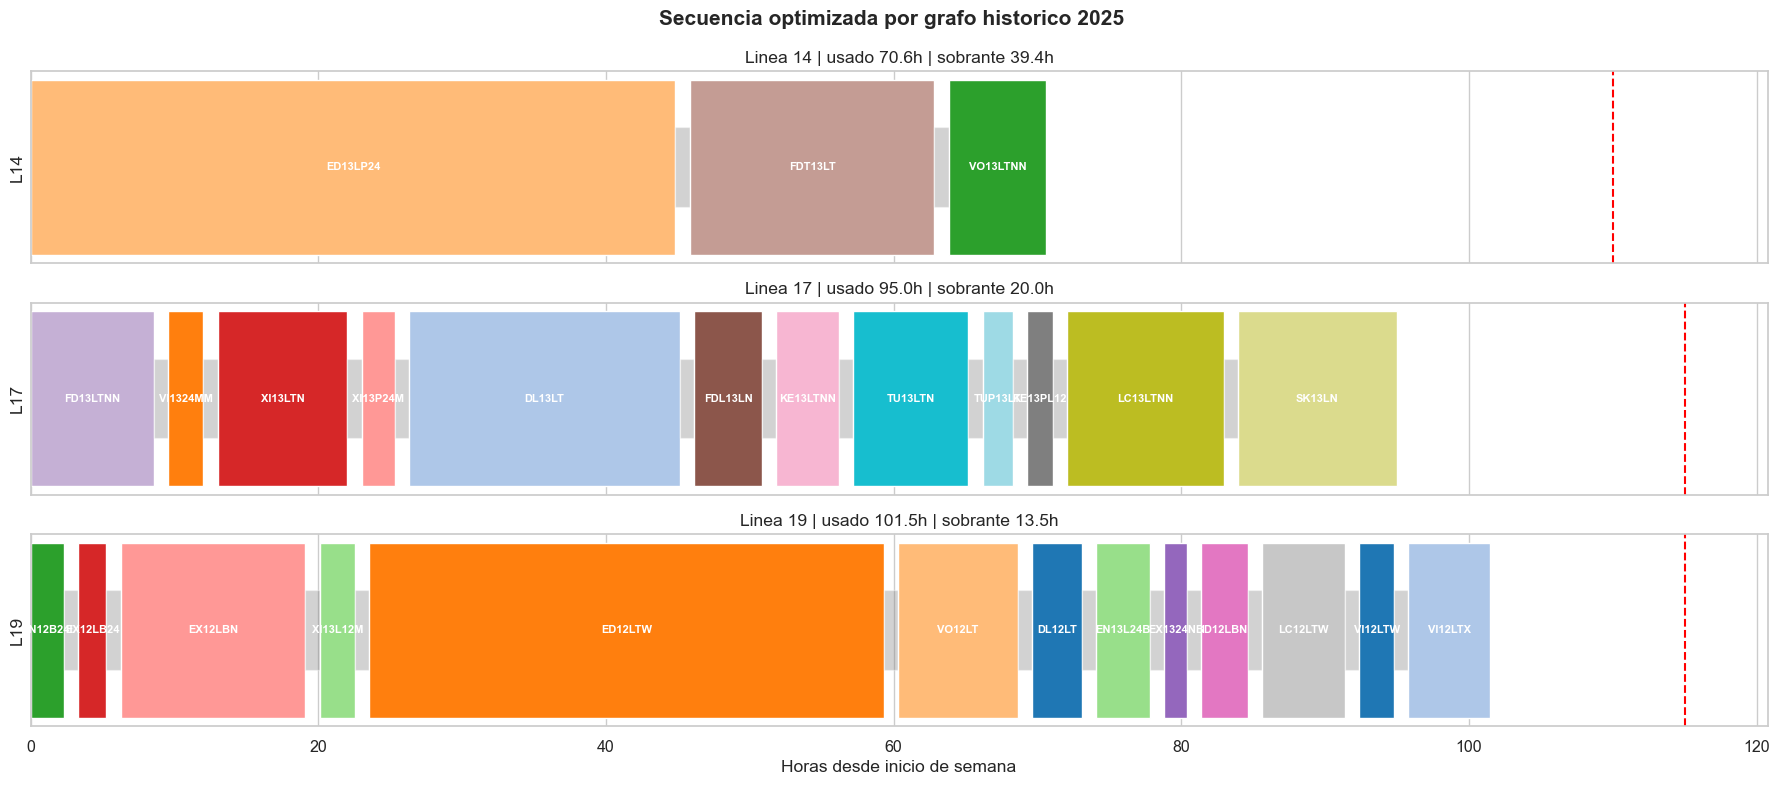

In [8]:
schedule_df = results['_schedule_df'].copy()
if schedule_df.empty:
    print('No hay schedule optimizado para visualizar.')
else:
    palette = dict(zip(sorted(schedule_df['sku'].unique()), sns.color_palette('tab20', n_colors=schedule_df['sku'].nunique())))
    fig, axes = plt.subplots(len(LINES), 1, figsize=(18, 8), sharex=True)
    if len(LINES) == 1:
        axes = [axes]
    for ax, line in zip(axes, LINES):
        det = schedule_df[schedule_df['line'] == line].sort_values('sequence_order')
        for _, item in det.iterrows():
            transition_h = float(item['transition_h'])
            prod_h = float(item['prod_h'])
            setup_start = max(float(item['start_h']) - transition_h, 0)
            if transition_h > 0:
                ax.barh(0, transition_h, left=setup_start, height=0.25, color='gray', alpha=0.35)
            ax.barh(0, prod_h, left=float(item['start_h']), height=0.55,
                    color=palette[item['sku']], edgecolor='white')
            if prod_h > 1.2:
                ax.text(float(item['start_h']) + prod_h / 2, 0, str(item['sku'])[:9],
                        ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        ax.axvline(HOURS_PER_WEEK[line], color='red', linestyle='--', lw=1.5)
        ax.set_title(f"Linea {line} | usado {results[line]['hours_optimized']:.1f}h | sobrante {results[line]['spare_hours']:.1f}h")
        ax.set_yticks([])
        ax.set_ylabel(f'L{line}')
    axes[-1].set_xlabel('Horas desde inicio de semana')
    plt.suptitle('Secuencia optimizada por grafo historico 2025', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7 · Arcos del grafo usados por la solucion

In [9]:
for line in LINES:
    r = results.get(line)
    if not r or not r['seq_optimized']:
        continue
    print(f"\nLinea {line}")
    seq = r['seq_optimized']
    edge_hours = r['edge_hours']
    for origin, dest in zip(seq, seq[1:]):
        print(f"  {origin:<12} -> {dest:<12}  {edge_hours.loc[origin, dest]:5.2f} h")


Linea 14
  ED13LP24     -> FDT13LT        1.00 h
  FDT13LT      -> VO13LTNN       1.00 h

Linea 17
  FD13LTNN     -> VI1324MM       1.00 h
  VI1324MM     -> XI13LTN        1.00 h
  XI13LTN      -> XI13P24M       1.00 h
  XI13P24M     -> DL13LT         1.00 h
  DL13LT       -> FDL13LN        1.00 h
  FDL13LN      -> KE13LTNN       1.00 h
  KE13LTNN     -> TU13LTN        1.00 h
  TU13LTN      -> TUP13LT        1.00 h
  TUP13LT      -> KE13PL12       1.00 h
  KE13PL12     -> LC13LTNN       1.00 h
  LC13LTNN     -> SK13LN         1.00 h

Linea 19
  EN12B24I     -> EX12LB24       1.00 h
  EX12LB24     -> EX12LBN        1.00 h
  EX12LBN      -> XI13L12M       1.00 h
  XI13L12M     -> ED12LTW        1.00 h
  ED12LTW      -> VO12LT         1.00 h
  VO12LT       -> DL12LT         1.00 h
  DL12LT       -> EN13L24B       1.00 h
  EN13L24B     -> EX1324NB       1.00 h
  EX1324NB     -> ID12LBN        1.00 h
  ID12LBN      -> LC12LTW        1.00 h
  LC12LTW      -> VI12LTW        1.00 h
  VI12LTW 